In [65]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/psrc0514/wifi-measurements/wifi_measurements.csv


# 1. CLEANING THE DATASET

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [67]:
df = pd.read_csv("/kaggle/input/datasets/psrc0514/wifi-measurements/wifi_measurements.csv")

print("Shape:", df.shape)
display(df.head())

Shape: (429, 12)


,Session,Location,Crowd Density,Time,BSSID,Signal (%),Signal (dBm),Ping (ms),Link (Mbps),DL (Mbps),UL (Mbps),Status
0,NIGHT,DISANG ROAD,1,0:25:24,Unknown,92,-54,525,72.2,0.0,0.0,DEGRADED
1,NIGHT,DISANG ROAD,1,0:25:30,Unknown,92,-54,152,72.2,0.0,0.0,DEGRADED
2,NIGHT,DISANG ROAD,1,0:25:36,Unknown,92,-54,553,72.2,0.0,0.0,DEGRADED
3,NIGHT,DISANG ROAD,1,0:25:42,Unknown,92,-54,356,72.2,0.0,0.0,DEGRADED
4,NIGHT,DISANG ROAD,1,0:25:47,Unknown,92,-54,399,72.2,0.0,0.0,DEGRADED


In [68]:
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
display(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Columns:
['Session', 'Location', 'Crowd Density', 'Time', 'BSSID', 'Signal (%)', 'Signal (dBm)', 'Ping (ms)', 'Link (Mbps)', 'DL (Mbps)', 'UL (Mbps)', 'Status']

Data types:
Session           object
Location          object
Crowd Density      int64
Time              object
BSSID             object
Signal (%)         int64
Signal (dBm)       int64
Ping (ms)          int64
Link (Mbps)      float64
DL (Mbps)        float64
UL (Mbps)        float64
Status            object
dtype: object

Missing values:


Session          0
Location         0
Crowd Density    0
Time             0
BSSID            0
Signal (%)       0
Signal (dBm)     0
Ping (ms)        0
Link (Mbps)      0
DL (Mbps)        0
UL (Mbps)        0
Status           0
dtype: int64


Duplicate rows:
0


In [69]:
for col in ["Session", "Location", "Crowd Density", "BSSID", "Status"]:
    print(f"\n===== {col} =====")
    print(df[col].value_counts(dropna=False))


===== Session =====
Session
MORNING    233
NIGHT      196
Name: count, dtype: int64

===== Location =====
Location
NEW SAC           81
CLASSROOM         65
CORE5 GF          64
ROADS             55
ADMIN BUILDING    39
CANTEEN           26
OPEN ROAD         23
new sac           20
LIBRARY           20
VISITOR ROOM      14
DISANG ROAD       12
HOSTEL ROOM       10
Name: count, dtype: int64

===== Crowd Density =====
Crowd Density
1    125
4    104
2     86
5     69
3     45
Name: count, dtype: int64

===== BSSID =====
BSSID
Unknown    418
NONE        11
Name: count, dtype: int64

===== Status =====
Status
DEGRADED    343
OK           86
Name: count, dtype: int64


In [70]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
)

print(df.columns.tolist())

['session', 'location', 'crowd_density', 'time', 'bssid', 'signal_%', 'signal_dbm', 'ping_ms', 'link_mbps', 'dl_mbps', 'ul_mbps', 'status']


In [71]:
text_columns = ["session", "location", "bssid", "status"]

for col in text_columns:
    df[col] = df[col].astype(str).str.strip().str.upper()

In [72]:
numeric_columns = [
    "crowd_density",
    "signal_%",
    "signal_dbm",
    "ping_ms",
    "link_mbps",
    "dl_mbps",
    "ul_mbps"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [73]:
print(df[numeric_columns].dtypes)

crowd_density      int64
signal_%           int64
signal_dbm         int64
ping_ms            int64
link_mbps        float64
dl_mbps          float64
ul_mbps          float64
dtype: object


In [74]:
print("Zero download measurements:")
display(
    df[df["dl_mbps"] == 0][
        ["session", "location", "time", "ping_ms", "dl_mbps", "ul_mbps", "status"]
    ].head(20)
)

Zero download measurements:


,session,location,time,ping_ms,dl_mbps,ul_mbps,status
0,NIGHT,DISANG ROAD,0:25:24,525,0.0,0.0,DEGRADED
1,NIGHT,DISANG ROAD,0:25:30,152,0.0,0.0,DEGRADED
2,NIGHT,DISANG ROAD,0:25:36,553,0.0,0.0,DEGRADED
3,NIGHT,DISANG ROAD,0:25:42,356,0.0,0.0,DEGRADED
4,NIGHT,DISANG ROAD,0:25:47,399,0.0,0.0,DEGRADED
5,NIGHT,DISANG ROAD,0:25:53,166,0.0,0.0,DEGRADED
12,NIGHT,NEW SAC,0:03:13,999,0.0,0.0,DEGRADED
13,NIGHT,NEW SAC,0:03:22,999,0.0,0.0,DEGRADED
32,NIGHT,CORE5 GF,0:33:41,999,0.0,0.0,DEGRADED
33,NIGHT,CORE5 GF,0:33:50,999,0.0,0.0,DEGRADED


In [75]:
print("Very high latency:")
display(
    df[df["ping_ms"] > 200][
        ["session", "location", "time", "ping_ms", "dl_mbps", "ul_mbps", "status"]
    ].head(20)
)

Very high latency:


,session,location,time,ping_ms,dl_mbps,ul_mbps,status
0,NIGHT,DISANG ROAD,0:25:24,525,0.00,0.00,DEGRADED
2,NIGHT,DISANG ROAD,0:25:36,553,0.00,0.00,DEGRADED
3,NIGHT,DISANG ROAD,0:25:42,356,0.00,0.00,DEGRADED
4,NIGHT,DISANG ROAD,0:25:47,399,0.00,0.00,DEGRADED
6,NIGHT,DISANG ROAD,0:25:58,245,9.56,5.62,DEGRADED
9,NIGHT,DISANG ROAD,0:26:15,770,9.56,5.62,DEGRADED
10,NIGHT,DISANG ROAD,0:26:21,307,9.56,5.62,DEGRADED
11,NIGHT,DISANG ROAD,0:26:27,226,9.56,5.62,DEGRADED
12,NIGHT,NEW SAC,0:03:13,999,0.00,0.00,DEGRADED
13,NIGHT,NEW SAC,0:03:22,999,0.00,0.00,DEGRADED


In [76]:
location_summary = (
    df.groupby("location")
      .agg(
          measurements=("location", "size"),
          avg_signal=("signal_%", "mean"),
          median_signal=("signal_%", "median"),
          avg_ping=("ping_ms", "mean"),
          median_ping=("ping_ms", "median"),
          avg_download=("dl_mbps", "mean"),
          median_download=("dl_mbps", "median"),
          avg_upload=("ul_mbps", "mean"),
          median_upload=("ul_mbps", "median"),
          avg_link=("link_mbps", "mean")
      )
      .reset_index()
)

display(
    location_summary.sort_values("median_download")
)

,location,measurements,avg_signal,median_signal,avg_ping,median_ping,avg_download,median_download,avg_upload,median_upload,avg_link
7,NEW SAC,101,86.207921,86.0,699.643564,999.0,5.654257,0.00,1.942079,0.00,261.673267
8,OPEN ROAD,23,22.304348,34.0,999.000000,999.0,0.943478,0.00,0.794348,0.00,186.847826
6,LIBRARY,20,75.600000,72.0,999.000000,999.0,38.122000,0.34,9.048000,0.00,373.755000
1,CANTEEN,26,46.692308,37.5,897.500000,999.0,2.820000,0.34,9.655385,6.52,79.750000
4,DISANG ROAD,12,92.000000,92.0,336.583333,276.0,4.780000,4.78,2.810000,2.81,72.200000
5,HOSTEL ROOM,10,90.000000,90.0,999.000000,999.0,3.633000,5.19,5.817000,8.31,144.400000
2,CLASSROOM,65,85.661538,84.0,999.000000,999.0,32.042308,8.67,22.259846,10.12,763.335385
3,CORE5 GF,64,77.062500,81.0,999.000000,999.0,14.393594,9.07,9.529844,3.25,239.775000
10,VISITOR ROOM,14,81.285714,83.0,999.000000,999.0,9.865714,11.51,7.688571,8.97,124.428571
0,ADMIN BUILDING,39,78.948718,80.0,449.000000,167.0,32.636410,40.46,17.766410,20.94,275.097436


In [77]:
session_data = (
    df.groupby(["session", "location"])
      .agg({
          "crowd_density": "median",
          "signal_%": "median",
          "signal_dbm": "median",
          "ping_ms": "median",
          "link_mbps": "median",
          "dl_mbps": "median",
          "ul_mbps": "median"
      })
      .reset_index()
)

# Rename the aggregated columns to clean names
session_data = session_data.rename(columns={
    "crowd_density": "crowd_density",
    "signal_%": "signal_percent",
    "signal_dbm": "signal_dbm",
    "ping_ms": "ping_ms",
    "link_mbps": "link_mbps",
    "dl_mbps": "dl_mbps",
    "ul_mbps": "ul_mbps"
})

# Number of individual readings contributing to each session
counts = (
    df.groupby(["session", "location"])
      .size()
      .reset_index(name="measurements")
)

session_data = session_data.merge(
    counts,
    on=["session", "location"]
)

display(session_data)

,session,location,crowd_density,signal_percent,signal_dbm,ping_ms,link_mbps,dl_mbps,ul_mbps,measurements
0,MORNING,ADMIN BUILDING,3.0,80.0,-60.0,999.0,130.0,54.58,32.64,15
1,MORNING,CANTEEN,2.0,61.0,-69.0,999.0,65.0,5.94,17.66,15
2,MORNING,CLASSROOM,5.0,89.0,-55.0,999.0,1201.0,56.52,43.98,28
3,MORNING,CORE5 GF,5.0,82.0,-59.0,999.0,144.4,9.83,3.25,41
4,MORNING,HOSTEL ROOM,3.0,90.0,-55.0,999.0,144.4,5.19,8.31,10
5,MORNING,LIBRARY,3.0,72.0,-63.5,999.0,144.4,0.34,0.00,20
6,MORNING,NEW SAC,4.0,83.0,-58.0,999.0,156.0,0.00,0.00,81
7,MORNING,OPEN ROAD,1.0,34.0,-83.0,999.0,286.5,0.00,0.00,23
8,NIGHT,ADMIN BUILDING,1.0,80.0,-60.0,77.5,433.3,19.20,10.25,24
9,NIGHT,CANTEEN,1.0,37.0,-81.0,999.0,97.5,0.34,6.52,11


In [78]:
download_pivot = df.pivot_table(
    index="location",
    columns="session",
    values="dl_mbps",
    aggfunc="median"
)

display(download_pivot)

session,MORNING,NIGHT
location,,
ADMIN BUILDING,54.58,19.20
CANTEEN,5.94,0.34
CLASSROOM,56.52,5.71
CORE5 GF,9.83,9.06
DISANG ROAD,NaN,4.78
HOSTEL ROOM,5.19,NaN
LIBRARY,0.34,NaN
NEW SAC,0.00,35.70
OPEN ROAD,0.00,NaN


In [79]:
ping_pivot = df.pivot_table(
    index="location",
    columns="session",
    values="ping_ms",
    aggfunc="median"
)

display(ping_pivot)

session,MORNING,NIGHT
location,,
ADMIN BUILDING,999.0,77.5
CANTEEN,999.0,999.0
CLASSROOM,999.0,999.0
CORE5 GF,999.0,999.0
DISANG ROAD,NaN,276.0
HOSTEL ROOM,999.0,NaN
LIBRARY,999.0,NaN
NEW SAC,999.0,118.0
OPEN ROAD,999.0,NaN


In [80]:
print(df.columns.tolist())

['session', 'location', 'crowd_density', 'time', 'bssid', 'signal_%', 'signal_dbm', 'ping_ms', 'link_mbps', 'dl_mbps', 'ul_mbps', 'status']


In [81]:
print(df["session"].value_counts())
print(df["location"].value_counts())

session
MORNING    233
NIGHT      196
Name: count, dtype: int64
location
NEW SAC           101
CLASSROOM          65
CORE5 GF           64
ROADS              55
ADMIN BUILDING     39
CANTEEN            26
OPEN ROAD          23
LIBRARY            20
VISITOR ROOM       14
DISANG ROAD        12
HOSTEL ROOM        10
Name: count, dtype: int64


In [82]:
display(location_summary.sort_values("median_download"))

,location,measurements,avg_signal,median_signal,avg_ping,median_ping,avg_download,median_download,avg_upload,median_upload,avg_link
7,NEW SAC,101,86.207921,86.0,699.643564,999.0,5.654257,0.00,1.942079,0.00,261.673267
8,OPEN ROAD,23,22.304348,34.0,999.000000,999.0,0.943478,0.00,0.794348,0.00,186.847826
6,LIBRARY,20,75.600000,72.0,999.000000,999.0,38.122000,0.34,9.048000,0.00,373.755000
1,CANTEEN,26,46.692308,37.5,897.500000,999.0,2.820000,0.34,9.655385,6.52,79.750000
4,DISANG ROAD,12,92.000000,92.0,336.583333,276.0,4.780000,4.78,2.810000,2.81,72.200000
5,HOSTEL ROOM,10,90.000000,90.0,999.000000,999.0,3.633000,5.19,5.817000,8.31,144.400000
2,CLASSROOM,65,85.661538,84.0,999.000000,999.0,32.042308,8.67,22.259846,10.12,763.335385
3,CORE5 GF,64,77.062500,81.0,999.000000,999.0,14.393594,9.07,9.529844,3.25,239.775000
10,VISITOR ROOM,14,81.285714,83.0,999.000000,999.0,9.865714,11.51,7.688571,8.97,124.428571
0,ADMIN BUILDING,39,78.948718,80.0,449.000000,167.0,32.636410,40.46,17.766410,20.94,275.097436


In [83]:
display(session_data)

,session,location,crowd_density,signal_percent,signal_dbm,ping_ms,link_mbps,dl_mbps,ul_mbps,measurements
0,MORNING,ADMIN BUILDING,3.0,80.0,-60.0,999.0,130.0,54.58,32.64,15
1,MORNING,CANTEEN,2.0,61.0,-69.0,999.0,65.0,5.94,17.66,15
2,MORNING,CLASSROOM,5.0,89.0,-55.0,999.0,1201.0,56.52,43.98,28
3,MORNING,CORE5 GF,5.0,82.0,-59.0,999.0,144.4,9.83,3.25,41
4,MORNING,HOSTEL ROOM,3.0,90.0,-55.0,999.0,144.4,5.19,8.31,10
5,MORNING,LIBRARY,3.0,72.0,-63.5,999.0,144.4,0.34,0.00,20
6,MORNING,NEW SAC,4.0,83.0,-58.0,999.0,156.0,0.00,0.00,81
7,MORNING,OPEN ROAD,1.0,34.0,-83.0,999.0,286.5,0.00,0.00,23
8,NIGHT,ADMIN BUILDING,1.0,80.0,-60.0,77.5,433.3,19.20,10.25,24
9,NIGHT,CANTEEN,1.0,37.0,-81.0,999.0,97.5,0.34,6.52,11


In [84]:
# Create a copy so we don't destroy the original raw data
analysis_df = df.copy()

# 999 appears to be the timeout/failure code
analysis_df["ping_failed"] = (
    analysis_df["ping_ms"] >= 999
).astype(int)

# Replace the artificial 999 with NaN
analysis_df["ping_clean"] = analysis_df["ping_ms"].replace(999, np.nan)

display(
    analysis_df[
        ["ping_ms", "ping_clean", "ping_failed"]
    ].head(20)
)

,ping_ms,ping_clean,ping_failed
0,525,525.0,0
1,152,152.0,0
2,553,553.0,0
3,356,356.0,0
4,399,399.0,0
5,166,166.0,0
6,245,245.0,0
7,182,182.0,0
8,158,158.0,0
9,770,770.0,0


In [85]:
# Create a copy so we don't destroy the original raw data
analysis_df = df.copy()

# 999 appears to be the timeout/failure code
analysis_df["ping_failed"] = (
    analysis_df["ping_ms"] >= 999
).astype(int)

# Replace the artificial 999 with NaN
analysis_df["ping_clean"] = analysis_df["ping_ms"].replace(999, np.nan)

display(
    analysis_df[
        ["ping_ms", "ping_clean", "ping_failed"]
    ].head(20)
)

,ping_ms,ping_clean,ping_failed
0,525,525.0,0
1,152,152.0,0
2,553,553.0,0
3,356,356.0,0
4,399,399.0,0
5,166,166.0,0
6,245,245.0,0
7,182,182.0,0
8,158,158.0,0
9,770,770.0,0


In [86]:
ping_failure_summary = (
    analysis_df
    .groupby(["session", "location"])
    .agg(
        total_measurements=("ping_ms", "size"),
        ping_failures=("ping_failed", "sum"),
        ping_failure_rate=("ping_failed", "mean")
    )
    .reset_index()
)

ping_failure_summary["ping_failure_rate"] *= 100

display(
    ping_failure_summary.sort_values(
        "ping_failure_rate",
        ascending=False
    )
)

,session,location,total_measurements,ping_failures,ping_failure_rate
0,MORNING,ADMIN BUILDING,15,15,100.000000
1,MORNING,CANTEEN,15,15,100.000000
2,MORNING,CLASSROOM,28,28,100.000000
3,MORNING,CORE5 GF,41,41,100.000000
4,MORNING,HOSTEL ROOM,10,10,100.000000
5,MORNING,LIBRARY,20,20,100.000000
7,MORNING,OPEN ROAD,23,23,100.000000
11,NIGHT,CORE5 GF,23,23,100.000000
15,NIGHT,VISITOR ROOM,14,14,100.000000
10,NIGHT,CLASSROOM,37,37,100.000000


In [87]:
ping_summary = (
    analysis_df
    .groupby(["session", "location"])
    .agg(
        median_ping=("ping_clean", "median"),
        mean_ping=("ping_clean", "mean"),
        ping_failure_rate=("ping_failed", "mean"),
        measurements=("location", "size")
    )
    .reset_index()
)

ping_summary["ping_failure_rate"] *= 100

display(ping_summary)

,session,location,median_ping,mean_ping,ping_failure_rate,measurements
0,MORNING,ADMIN BUILDING,NaN,NaN,100.000000,15
1,MORNING,CANTEEN,NaN,NaN,100.000000,15
2,MORNING,CLASSROOM,NaN,NaN,100.000000,28
3,MORNING,CORE5 GF,NaN,NaN,100.000000,41
4,MORNING,HOSTEL ROOM,NaN,NaN,100.000000,10
5,MORNING,LIBRARY,NaN,NaN,100.000000,20
6,MORNING,NEW SAC,110.0,274.111111,69.135802,81
7,MORNING,OPEN ROAD,NaN,NaN,100.000000,23
8,NIGHT,ADMIN BUILDING,77.5,105.250000,0.000000,24
9,NIGHT,CANTEEN,187.0,471.200000,63.636364,11


In [88]:
connectivity_summary = (
    analysis_df
    .groupby(["session", "location"])
    .agg(
        measurements=("location", "size"),

        median_download=("dl_mbps", "median"),
        median_upload=("ul_mbps", "median"),

        median_ping=("ping_clean", "median"),
        ping_failure_rate=("ping_failed", "mean"),

        median_signal=("signal_%", "median"),
        median_signal_dbm=("signal_dbm", "median"),

        zero_download_rate=("dl_mbps", lambda x: (x == 0).mean()),

        crowd_density=("crowd_density", "median")
    )
    .reset_index()
)

connectivity_summary["ping_failure_rate"] *= 100
connectivity_summary["zero_download_rate"] *= 100

display(connectivity_summary)

,session,location,measurements,median_download,median_upload,median_ping,ping_failure_rate,median_signal,median_signal_dbm,zero_download_rate,crowd_density
0,MORNING,ADMIN BUILDING,15,54.58,32.64,NaN,100.000000,80.0,-60.0,20.000000,3.0
1,MORNING,CANTEEN,15,5.94,17.66,NaN,100.000000,61.0,-69.0,20.000000,2.0
2,MORNING,CLASSROOM,28,56.52,43.98,NaN,100.000000,89.0,-55.0,10.714286,5.0
3,MORNING,CORE5 GF,41,9.83,3.25,NaN,100.000000,82.0,-59.0,14.634146,5.0
4,MORNING,HOSTEL ROOM,10,5.19,8.31,NaN,100.000000,90.0,-55.0,30.000000,3.0
5,MORNING,LIBRARY,20,0.34,0.00,NaN,100.000000,72.0,-63.5,20.000000,3.0
6,MORNING,NEW SAC,81,0.00,0.00,110.0,69.135802,83.0,-58.0,66.666667,4.0
7,MORNING,OPEN ROAD,23,0.00,0.00,NaN,100.000000,34.0,-83.0,69.565217,1.0
8,NIGHT,ADMIN BUILDING,24,19.20,10.25,77.5,0.000000,80.0,-60.0,16.666667,1.0
9,NIGHT,CANTEEN,11,0.34,6.52,187.0,63.636364,37.0,-81.0,45.454545,1.0


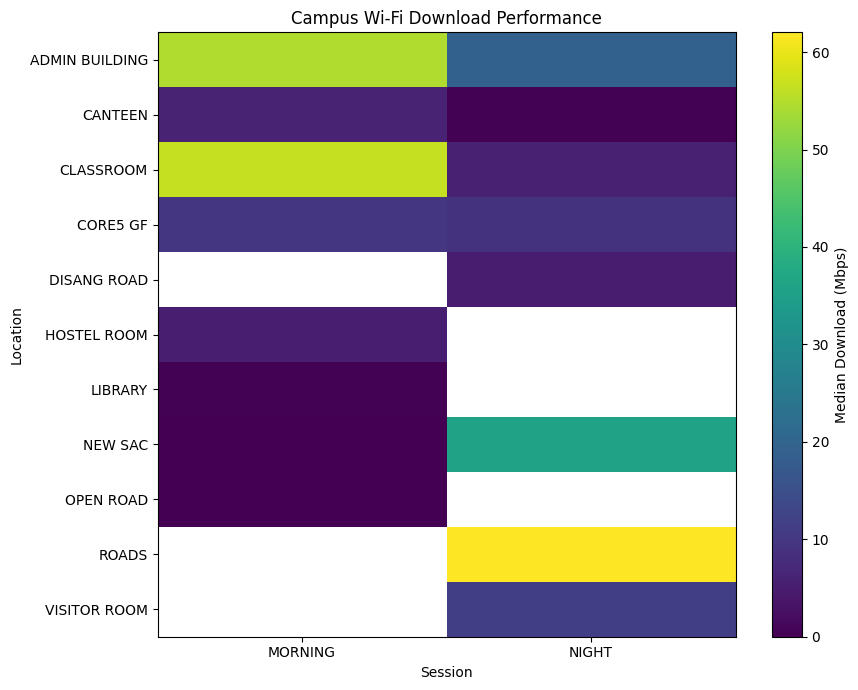

In [89]:
download_pivot = connectivity_summary.pivot(
    index="location",
    columns="session",
    values="median_download"
)

plt.figure(figsize=(9, 7))

plt.imshow(
    download_pivot,
    aspect="auto"
)

plt.xticks(
    range(len(download_pivot.columns)),
    download_pivot.columns
)

plt.yticks(
    range(len(download_pivot.index)),
    download_pivot.index
)

plt.colorbar(label="Median Download (Mbps)")

plt.xlabel("Session")
plt.ylabel("Location")
plt.title("Campus Wi-Fi Download Performance")

plt.tight_layout()
plt.show()

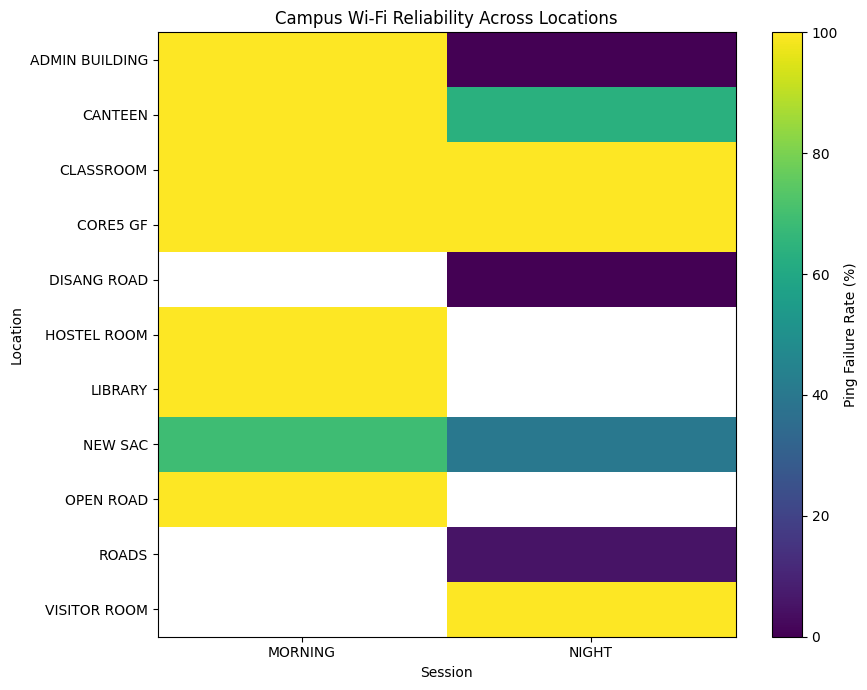

In [90]:
failure_pivot = connectivity_summary.pivot(
    index="location",
    columns="session",
    values="ping_failure_rate"
)

plt.figure(figsize=(9, 7))

plt.imshow(
    failure_pivot,
    aspect="auto"
)

plt.xticks(
    range(len(failure_pivot.columns)),
    failure_pivot.columns
)

plt.yticks(
    range(len(failure_pivot.index)),
    failure_pivot.index
)

plt.colorbar(label="Ping Failure Rate (%)")

plt.xlabel("Session")
plt.ylabel("Location")
plt.title("Campus Wi-Fi Reliability Across Locations")

plt.tight_layout()
plt.show()

In [91]:
crowd_analysis = (
    analysis_df
    .groupby("crowd_density")
    .agg(
        median_download=("dl_mbps", "median"),
        median_upload=("ul_mbps", "median"),
        ping_failure_rate=("ping_failed", "mean"),
        median_signal=("signal_%", "median"),
        zero_download_rate=("dl_mbps", lambda x: (x == 0).mean()),
        measurements=("location", "size")
    )
    .reset_index()
)

crowd_analysis["ping_failure_rate"] *= 100
crowd_analysis["zero_download_rate"] *= 100

display(crowd_analysis)

,crowd_density,median_download,median_upload,ping_failure_rate,median_signal,zero_download_rate,measurements
0,1,3.860,6.520,26.400000,86.0,38.400000,125
1,2,7.305,9.245,86.046512,83.0,11.627907,86
2,3,5.190,8.310,100.000000,81.0,22.222222,45
3,4,0.000,0.000,75.961538,83.0,53.846154,104
4,5,11.770,20.760,100.000000,85.0,13.043478,69


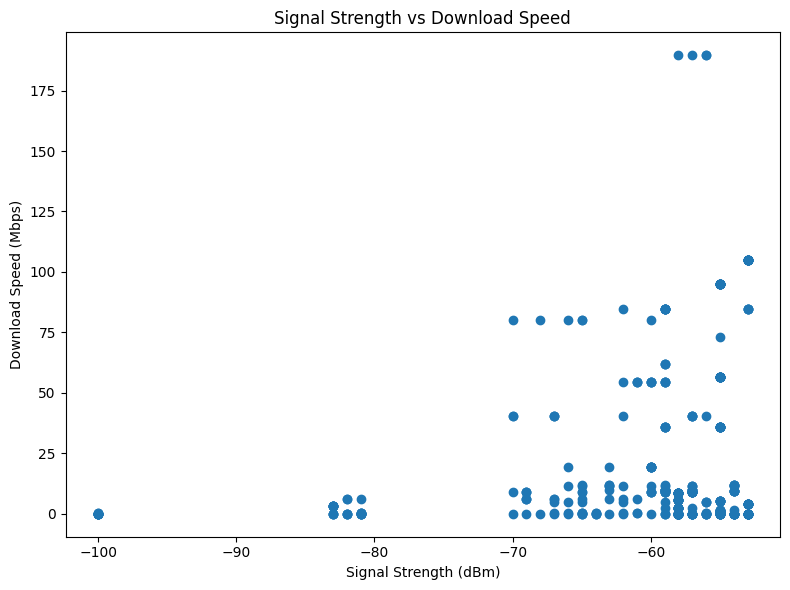

In [92]:
plt.figure(figsize=(8, 6))

plt.scatter(
    analysis_df["signal_dbm"],
    analysis_df["dl_mbps"]
)

plt.xlabel("Signal Strength (dBm)")
plt.ylabel("Download Speed (Mbps)")
plt.title("Signal Strength vs Download Speed")

plt.tight_layout()
plt.show()